<a href="https://colab.research.google.com/github/hopeof-Greatmind/NLP_Basic/blob/main/kobert_sentiment_finetunning_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KoBERT Fine-tuning 실습: 한국어 감정 인식

이 노트북은 Google Colab에서 KoBERT 계열 모델을 fine-tuning하여 한국어 감성분석/감정 인식을 수행하는 예제입니다.

- Task: 한국어 문장 긍정/부정 분류
- Dataset: NSMC 네이버 영화 리뷰 데이터셋
- Model: `skt/kobert-base-v1`
- Framework: Hugging Face Transformers + Datasets + Trainer

Colab 상단 메뉴에서 **런타임 > 런타임 유형 변경 > GPU**를 선택한 뒤 실행하세요.

In [ ]:
!pip install -q transformers datasets accelerate evaluate scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


## 1. 라이브러리 로드 및 환경 설정

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# AUTO-INJECTED: Korean font setup for matplotlib
import os as _os
import matplotlib.font_manager as _fm
import matplotlib.pyplot as _plt
if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
    for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                  '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
        if _os.path.exists(_font):
            _fm.fontManager.addfont(_font)
_plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
del _os, _fm, _plt
# END AUTO-INJECTED Korean font setup


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cuda


## 2. 데이터셋 로드: NSMC

In [ ]:
from datasets import load_dataset
import pandas as pd

# 시스템 명령어로 데이터 직접 다운로드
!wget -O ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget -O ratings_test.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

# 로컬 파일에서 로드 (오류를 유발하던 skip_empty_lines 제거)
dataset = load_dataset(
    "csv",
    data_files={
        "train": "ratings_train.txt",
        "test": "ratings_test.txt"
    },
    delimiter="\t",
    column_names=["id", "document", "label"],
    skiprows=1
)

# 'id' 컬럼 제거
dataset = dataset.remove_columns("id")

print("데이터셋 로드 완료:")
print(dataset)

--2026-06-12 02:16:34--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  --.-KB/s    in 0.08s   

2026-06-12 02:16:34 (167 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-06-12 02:16:34--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet-

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

데이터셋 로드 완료:
DatasetDict({
    train: Dataset({
        features: ['document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['document', 'label'],
        num_rows: 50000
    })
})


In [ ]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())
print(train_df["label"].value_counts())

                                            document  label
0                                아 더빙.. 진짜 짜증나네요 목소리      0
1                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2                                  너무재밓었다그래서보는것을추천한다      0
3                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1
label
0    75173
1    74827
Name: count, dtype: int64


In [ ]:
label_map = {0: "부정", 1: "긍정"}

for i in range(5):
    print("문장:", train_df.loc[i, "document"])
    print("라벨:", label_map[train_df.loc[i, "label"]])
    print("-" * 50)

문장: 아 더빙.. 진짜 짜증나네요 목소리
라벨: 부정
--------------------------------------------------
문장: 흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
라벨: 긍정
--------------------------------------------------
문장: 너무재밓었다그래서보는것을추천한다
라벨: 부정
--------------------------------------------------
문장: 교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
라벨: 부정
--------------------------------------------------
문장: 사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다
라벨: 긍정
--------------------------------------------------


## 3. 실습용 데이터 크기 축소

Colab 실습 시간을 줄이기 위해 subset을 사용합니다. 전체 데이터로 학습하려면 `select(range(...))` 부분을 제거하거나 범위를 늘리세요.

In [ ]:
small_train = dataset["train"].shuffle(seed=42).select(range(10000))
small_valid = dataset["test"].shuffle(seed=42).select(range(2000))
small_test = dataset["test"].shuffle(seed=123).select(range(2000))

print(small_train)
print(small_valid)
print(small_test)

Dataset({
    features: ['document', 'label'],
    num_rows: 10000
})
Dataset({
    features: ['document', 'label'],
    num_rows: 2000
})
Dataset({
    features: ['document', 'label'],
    num_rows: 2000
})


## 4. KoBERT 모델 및 토크나이저 로딩

In [ ]:
model_name = "skt/kobert-base-v1"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1},
    trust_remote_code=True
)

model.to(device)

config.json:   0%|          | 0.00/535 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/371k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: skt/kobert-base-v1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(8002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, 

### 대체 모델 옵션

KoBERT tokenizer 로드 문제가 발생하면 아래 셀의 주석을 해제하여 `klue/bert-base`를 사용할 수 있습니다.

In [ ]:
# model_name = "klue/bert-base"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
# model.to(device)

## 5. 전처리 및 토큰화

In [ ]:
def preprocess_function(examples):
    texts = []
    labels = []
    for text, label in zip(examples["document"], examples["label"]):
        if text is not None and len(text.strip()) > 0:
            texts.append(text)
            labels.append(label)
    tokenized = tokenizer(texts, truncation=True, max_length=128)
    tokenized["labels"] = labels
    return tokenized

tokenized_train = small_train.map(preprocess_function, batched=True, remove_columns=small_train.column_names)
tokenized_valid = small_valid.map(preprocess_function, batched=True, remove_columns=small_valid.column_names)
tokenized_test = small_test.map(preprocess_function, batched=True, remove_columns=small_test.column_names)

print(tokenized_train[0])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'input_ids': [648, 430, 638, 375, 420, 54, 492, 0, 517, 0, 491, 494, 490, 0, 491, 0, 517, 0, 494, 0, 493, 0, 517, 492, 0, 517, 0, 491, 494, 490, 0, 491, 0, 517, 0, 54, 3, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 1}


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 6. 평가 지표 정의

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

## 7. 학습 설정 및 Trainer 구성

In [ ]:
training_args = TrainingArguments(
    output_dir="./kobert-nsmc-sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# Trainer에서 tokenizer 인자를 제거하여 TypeError 해결
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

## 8. Fine-tuning 실행: 실제 학습 실행

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.693501,0.693413,0.522000,0.503074,0.930714,0.653120
2,0.675054,0.666354,0.583500,0.695906,0.246122,0.363636
3,0.644909,0.659872,0.587500,0.556529,0.722854,0.628880


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.67545234375, metrics={'train_runtime': 250.6198, 'train_samples_per_second': 119.703, 'train_steps_per_second': 7.481, 'total_flos': 1712910525936960.0, 'train_loss': 0.67545234375, 'epoch': 3.0})

## 9. 검증 및 테스트 평가

In [ ]:
valid_result = trainer.evaluate(tokenized_valid)
valid_result

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.644909,0.693413,3,0.522000,0.503074,0.930714,0.653120


{'eval_loss': 0.6934125423431396,
 'eval_accuracy': 0.522,
 'eval_precision': 0.5030743432084964,
 'eval_recall': 0.9307135470527405,
 'eval_f1': 0.6531204644412192}

In [ ]:
test_result = trainer.evaluate(tokenized_test)
test_result

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.644909,0.682360,3,0.537000,0.518621,0.939577,0.668338


{'eval_loss': 0.6823604702949524,
 'eval_accuracy': 0.537,
 'eval_precision': 0.5186214563646471,
 'eval_recall': 0.9395770392749244,
 'eval_f1': 0.6683381088825215}

## 10. 상세 성능 분석

In [ ]:
pred_output = trainer.predict(tokenized_test)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print(classification_report(y_true, y_pred, target_names=["부정", "긍정"], digits=4))

              precision    recall  f1-score   support

          부정     0.7015    0.1400    0.2334      1007
          긍정     0.5186    0.9396    0.6683       993

    accuracy                         0.5370      2000
   macro avg     0.6101    0.5398    0.4509      2000
weighted avg     0.6107    0.5370    0.4494      2000



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44557 (\N{HANGUL SYLLABLE GEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/

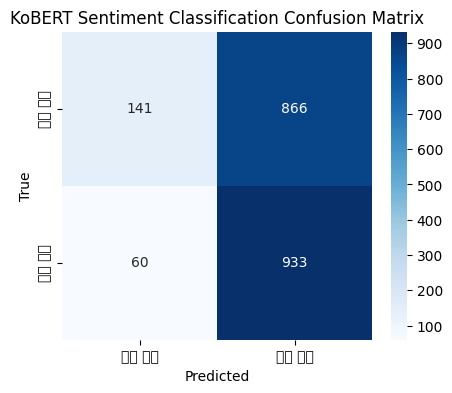

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["부정 예측", "긍정 예측"],
    yticklabels=["부정 실제", "긍정 실제"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KoBERT Sentiment Classification Confusion Matrix")
plt.show()

## 11. 모델 저장 및 재로드

In [ ]:
save_dir = "./kobert-nsmc-finetuned"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print("Saved to:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./kobert-nsmc-finetuned


In [ ]:
loaded_tokenizer = AutoTokenizer.from_pretrained(save_dir, trust_remote_code=True)
loaded_model = AutoModelForSequenceClassification.from_pretrained(save_dir, trust_remote_code=True)
loaded_model.to(device)
loaded_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(8002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, 

## 12. 단일 문장 감정 예측: 실제 예시 문장으로 테스트 수행


In [ ]:
def predict_sentiment(text):
    inputs = loaded_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = loaded_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
    return {
        "text": text,
        "prediction": label_map[pred],
        "negative_prob": probs[0][0].item(),
        "positive_prob": probs[0][1].item()
    }

examples = [
    "정말 감동적인 영화였습니다. 다시 보고 싶어요.",
    "시간이 너무 아까웠고 배우들의 연기도 별로였습니다.",
    "스토리는 평범했지만 음악과 영상미가 좋았습니다.",
    "최악입니다. 돈이 아까워요.",
    "기대 이상으로 재미있었습니다."
]

for text in examples:
    result = predict_sentiment(text)
    print(f"입력 문장: {result['text']}")
    print(f"예측 감정: {result['prediction']}")
    print(f"부정 확률: {result['negative_prob']:.4f}")
    print(f"긍정 확률: {result['positive_prob']:.4f}")
    print("-" * 60)

입력 문장: 정말 감동적인 영화였습니다. 다시 보고 싶어요.
예측 감정: 긍정
부정 확률: 0.4607
긍정 확률: 0.5393
------------------------------------------------------------
입력 문장: 시간이 너무 아까웠고 배우들의 연기도 별로였습니다.
예측 감정: 긍정
부정 확률: 0.4602
긍정 확률: 0.5398
------------------------------------------------------------
입력 문장: 스토리는 평범했지만 음악과 영상미가 좋았습니다.
예측 감정: 긍정
부정 확률: 0.4600
긍정 확률: 0.5400
------------------------------------------------------------
입력 문장: 최악입니다. 돈이 아까워요.
예측 감정: 긍정
부정 확률: 0.4586
긍정 확률: 0.5414
------------------------------------------------------------
입력 문장: 기대 이상으로 재미있었습니다.
예측 감정: 긍정
부정 확률: 0.4603
긍정 확률: 0.5397
------------------------------------------------------------


In [ ]:
user_text = input("감정을 분석할 한국어 문장을 입력하세요: ")
result = predict_sentiment(user_text)
print("입력 문장:", result["text"])
print("예측 감정:", result["prediction"])
print("부정 확률:", round(result["negative_prob"], 4))
print("긍정 확률:", round(result["positive_prob"], 4))

감정을 분석할 한국어 문장을 입력하세요: 오늘은 너무 힘들어요.
입력 문장: 오늘은 너무 힘들어요.
예측 감정: 긍정
부정 확률: 0.4564
긍정 확률: 0.5436


## 13. 오분류 샘플 분석

In [ ]:
test_texts = []
for item in small_test:
    text = item["document"]
    label = item["label"]
    if text is not None and len(text.strip()) > 0:
        test_texts.append((text, label))

error_cases = []
for i, (text, true_label) in enumerate(test_texts[:len(y_pred)]):
    pred_label = y_pred[i]
    if true_label != pred_label:
        error_cases.append({
            "text": text,
            "true_label": label_map[true_label],
            "pred_label": label_map[pred_label]
        })

error_df = pd.DataFrame(error_cases)
print("오분류 개수:", len(error_df))
print("오분류 비율:", len(error_df) / len(y_pred))
error_df.head(20)

오분류 개수: 926
오분류 비율: 0.463


,text,true_label,pred_label
0,놀라운건 시내 추격전에서 사람이 화살 맞고 죽는데도 시민들은 깜짝도 않하고 지나간다 ㅡㅡ,부정,긍정
1,3류독립영화보다못한영화 그냥보는 내내답답한 영화 시간낭비 스릴러냐이게 드라마지 10...,부정,긍정
2,용가리 치킨때문에 1점 더해준다.. 심형래 국뽕마케팅 아녔음 용가리 치킨도 안나왔겠지,부정,긍정
3,이게 왜 평점이 높은지 이해불가... 날라리 30대남자에게 철없는 어린마음에 몸까지...,부정,긍정
4,공포는 있지만 줄거리는 그닥,부정,긍정
5,홍련의 화살 다음이야기를 영화로 만들던가 시나리오 개판에 미카사는 왠 태국여자 등장...,부정,긍정
6,그린랜턴이라는 소재를 이따구로 날리냐,부정,긍정
7,"""평점이 지나치게 높게 책정된것 같아 1점으로 합니다.우선 1,2에 비해 악당이 너...",부정,긍정
8,주인공이 더 악당인영화재미있을 려고 영화봤는데더 스트레스받는 영화...,부정,긍정
9,.,긍정,부정
